# Spectrum reconstruction under growing perturbation: baseline against the penalized model

`part_5` established that the Fisher-Rao spectral-plus-hinge penalty makes the encoder
measurably harder to displace, and did so as an aggregate over 2000 pixels and 45 models.
This notebook shows that effect on individual spectra, at the level a reader can inspect:
the same spectrum, perturbed step by step, reconstructed side by side by two models.

Two models are compared. The unregularized baseline and the penalized model at
$\lambda=2\times10^{-3}$, which is the candidate whose robustness gain `part_5` found most
reproducible across seeds. `part_0_3` covers what the perturbations do to the input itself,
without any model; this notebook is the model-facing half of that pair.

## Introduction

The question is whether the smaller latent displacement `part_5` measured actually reaches
the output. A penalty that stabilizes the code without stabilizing the reconstruction would
be regularizing a quantity that does not propagate, and only a comparison at the level of
the decoded spectrum can tell.

Three things are tracked as the perturbation grows:

- the **perturbed input** itself, so the size of the change being asked about is visible;
- each model's **reconstruction**, so their responses can be compared directly;
- the **disagreement between the two models**, drawn as the band between their
  reconstructions. It starts near zero on clean input, where both models do the same job,
  and any growth in it with amplitude is the penalty's effect made visible.

### Assumptions

- **Both models were trained with the same reconstruction objective** and differ only in the
  encoder's contractive term, so a difference in reconstruction under perturbation is
  attributable to the encoder rather than to the decoder or the loss.
- **Both models retain the same latent variation.** `part_4` measured the penalized model at
  103.5% of the baseline's latent trace, so a smaller response here is robustness and not
  the collapse that `part_2` documented for the Euclidean penalty. Without that check a
  model that simply ignores its input would look best on every figure in this notebook.
- **Movement is measured against each model's own clean reconstruction**, not against the
  input. The question is how far a model's output moves when its input is perturbed;
  how faithfully it reconstructs in the first place is a separate matter.
- **Both models see identical inputs**, including identical noise draws for the stochastic
  perturbation families at every amplitude, so the comparison is paired at the spectrum
  level.
- **Distances between spectra use the training objective, not the Euclidean norm.** Both
  models minimize `MassersteinLoss`, a transport cost on the m/z grid, and the campaign's
  premise is that a one-bin displacement is a small chemical change. A Euclidean distance
  contradicts that premise: with peaks about one bin wide it rates a one-bin shift as a
  near-total change. Every distance reported here is therefore the Masserstein cost, computed
  with `masserstein_distances`, the same implementation the reconstruction analyses use.
  Euclidean values are persisted alongside for continuity but are not plotted.
- **The zoom window is fixed across amplitudes.** It is centred on the strongest peak of the
  clean spectrum and does not follow the perturbation, so a displacement is visible as the
  structure moving inside the window rather than as the window moving with it.
- **One spectrum is displayed, the whole sample is measured.** The figures follow fixed,
  deterministically chosen spectra identified by dataset index; every curve and distribution
  uses the full sample.

### Notation

For a spectrum $x$ and transform $T$, write $\delta=T(x)-x$ after TIC renormalization and
$x_t=\mathrm{TIC}(x+t\delta)$ for amplitude $t$. For model $m$ with encoder and decoder
$\mathrm{Enc}_m,\mathrm{Dec}_m$, the reconstruction is
$\hat x^m_t=\mathrm{Dec}_m(\mathrm{Enc}_m(x_t))$ and $q_m(x_t)$ the unit latent direction.
Three quantities are reported: the latent displacement $\angle(q_m(x_0),q_m(x_t))$ in
degrees, the reconstruction drift $W(\hat x^m_t,\hat x^m_0)$, and the between-model
disagreement $W(\hat x^{A}_t,\hat x^{B}_t)$, where $W$ is the Masserstein transport cost on
the binner's m/z grid, the same distance the models were trained to minimize.

In [1]:
import hashlib
import json
import os
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader import read_entropy_campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import penalty_sweep as sweep
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import sweep_evaluation as evaluation
from msi_autoencoder_wrapper.analysis.autoencoder.latent import perturbations as perturbation
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.analysis.autoencoder.latent.sensitivity import (
    canonical_direction, paired_direction_angles,
)
from msi_autoencoder_wrapper.analysis.autoencoder.reconstruction.metrics import masserstein_distances
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points
from msi_autoencoder_wrapper.visualization.spectra.views import plot_spectrum_comparison

logger = get_custom_logger("spectrum_reconstruction")

2026-09-07 22:30:43,982 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-07 22:30:43,986 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-07 22:30:44,695 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-07 22:30:44,697 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-07 22:30:44,698 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-07 22:30:44,699 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 22:30:44,714 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-07 22:30:44,831 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 21 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-07 22:30:44,832 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 25 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Configuration and the two compared models

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
MODEL_STORE = WORKSPACE / "models" / MODEL_CONTEXT

ACTIVATION_CAMPAIGN = "fisher-rao-hinge-activation-20260907-01"
BASELINE_CAMPAIGN = "bce-baseline-20260905-01"

BASELINE_CELL = "baseline (no contractive)"
PENALIZED_CELL = "fisher_rao / spectral_plus_hinged / w=2e-03 / tau=7"
COMPARED = {"baseline": BASELINE_CELL, "hinge 2e-3": PENALIZED_CELL}
REPETITION = 0

TARGET_FIELD = "molecule"
BATCH_SIZE = 256
SAMPLE_SEED = 42
DECODE_CACHE = Path("data/kidney_workspace/cache/materialized_splits")

PERTURBATION_SETTINGS = perturbation.PerturbationSettings(
    shift_bins=1, extra_width_sigma=1.0, base_width_sigma=0.42,
    lognormal_sigma=0.05, noise_fraction=0.02,
)
DISPLAY_AMPLITUDES = (0.0, 0.1, 0.5, 1.0)
CURVE_AMPLITUDES = (0.0, 0.05, 0.1, 0.25, 0.5, 0.75, 1.0)
SAMPLE_PIXELS = 2000
SHOWN_SPECTRA = 3
ZOOM_HALF_WIDTH_MZ = 15.0

ARTIFACT_DIR = Path("assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_6_spectrum_reconstruction_results")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

theme = resolve_theme(None)
theme.apply()

grid_rows = []
for campaign_id in (ACTIVATION_CAMPAIGN, BASELINE_CAMPAIGN):
    status = WORKSPACE / "configs" / "entropy-runs" / campaign_id / "plan" / "status"
    tasks = read_entropy_campaign(status, MODEL_STORE, load_artifacts=False)
    grid_rows += [
        row for row in sweep.sweep_grid_frame(tasks, campaign_id)
        if row["status"] == "completed" and row["cell_label"] in COMPARED.values()
        and row["repetition"] == REPETITION
    ]
grid_frame = pd.DataFrame(grid_rows)
model_name_by_cell = dict(zip(grid_frame["cell_label"], grid_frame["model_name"]))
display(grid_frame[["campaign", "cell_label", "model_name", "repetition"]])

2026-09-07 22:30:44,978 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 20 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/fisher-rao-hinge-activation-20260907-01/plan/status'.


2026-09-07 22:30:45,198 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/fisher-rao-hinge-activation-20260907-01/plan/status': 20 task(s) read.


2026-09-07 22:30:45,199 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'fisher-rao-hinge-activation-20260907-01': 20 task(s), 20 completed, 4 distinct grid cell(s).


2026-09-07 22:30:45,200 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 5 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status'.


2026-09-07 22:30:45,248 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:97 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status': 5 task(s) read.


2026-09-07 22:30:45,248 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.penalty_sweep:230 | Campaign 'bce-baseline-20260905-01': 5 task(s), 5 completed, 1 distinct grid cell(s).


,campaign,cell_label,model_name,repetition
0,fisher-rao-hinge-activation-20260907-01,fisher_rao / spectral_plus_hinged / w=2e-03 / ...,fisher-rao-hinge-activation-20260907-01__task_...,0
1,bce-baseline-20260905-01,baseline (no contractive),bce-baseline-20260905-01__task_000000,0


In [3]:
evaluation.link_campaign_scratch_workspace(f"/tmp/ms488923/msi-wrapper/{ACTIVATION_CAMPAIGN}/workspace", WORKSPACE)

wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)
wrapper.load_configuration(model_name=model_name_by_cell[PENALIZED_CELL])
partitions = wrapper.active_dataset.create_partitions()

test_split = evaluation.materialize_split(
    partitions, "test", TARGET_FIELD, fraction=1.0, seed=SAMPLE_SEED, cache_directory=DECODE_CACHE,
)
sample_rng = np.random.default_rng(SAMPLE_SEED)
selection = (
    np.sort(sample_rng.choice(test_split.sampled, SAMPLE_PIXELS, replace=False))
    if test_split.sampled > SAMPLE_PIXELS else np.arange(test_split.sampled)
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
clean = test_split.spectra[selection].to(device)  # (N, M)
bins = clean.shape[1]
# The binner's own grid, not a reconstructed one: the analysis must not assume a
# spacing the binner is free to define.
mass_axis = np.asarray(wrapper.active_context.binner.GetXAxis(), dtype=float)
if mass_axis.shape[0] != bins:
    raise ValueError(f"Binner axis has {mass_axis.shape[0]} bins, spectra have {bins}.")

peak_counts = (clean > clean.mean(dim=1, keepdim=True)).sum(dim=1).cpu().numpy()
shown_rows = np.argsort(-peak_counts)[:SHOWN_SPECTRA]
focus_row = int(shown_rows[0])
print(f"{clean.shape[0]} spectra, {bins} bins; focus spectrum is dataset index {test_split.indices[selection][focus_row]}")

models = {}
for label, cell in COMPARED.items():
    model = wrapper.models_manager.load_model(
        img_name=MODEL_CONTEXT, model_name=model_name_by_cell[cell], strict=True
    )
    model.eval()
    models[label] = model
print("loaded:", list(models))

2026-09-07 22:30:45,333 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-09-07 22:30:45,335 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-09-07 22:30:45,336 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-09-07 22:30:45,337 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-07 22:30:45,337 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-09-07 22:31:51,629 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-09-07 22:31:51,630 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-07 22:31:51,633 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-07 22:31:51,640 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


loaded: ['baseline', 'hinge 2e-3']


In [4]:
MODEL_COLOR = {"baseline": theme.color_for_model("baseline", 0), "hinge 2e-3": theme.color_for_model("hinge", 2)}
DISAGREEMENT_COLOR = theme.color_for_model("disagreement", 4)


def reconstruct(model, spectra: torch.Tensor) -> torch.Tensor:
    outputs = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            outputs.append(model(spectra[start : start + BATCH_SIZE])["reconstruction"])  # (B, M)
    return torch.cat(outputs)  # (N, M)


def latent_directions(model, spectra: torch.Tensor) -> torch.Tensor:
    gamma, beta = geometry.encoder_layer_norm_parameters(model)
    gamma_tensor = torch.as_tensor(gamma, device=spectra.device)
    beta_tensor = torch.as_tensor(beta, device=spectra.device)
    directions = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            latent = model(spectra[start : start + BATCH_SIZE])["latent_space"]
            directions.append(canonical_direction(latent, gamma_tensor, beta_tensor)[1])
    return torch.cat(directions)  # (N, D)


def display_limit(traces: list, window: np.ndarray, quantile: float = 0.995) -> tuple[float, float]:
    """Vertical limit driven by the bulk of the signal, not by the base peak.

    REMARK: a TIC-normalized MSI spectrum is dominated by one peak that is an order of
    magnitude above everything else, so scaling to the maximum flattens every other bin
    onto the axis and the reconstruction becomes an apparently flat line at zero. The
    limit is therefore taken from a high quantile of all displayed values, and the base
    peak is allowed to clip; its true height is annotated on the panel so nothing is
    hidden silently.
    """
    values = np.concatenate([np.asarray(trace)[window] for trace in traces])
    limit = float(np.quantile(values, quantile))
    peak = float(values.max())
    if limit <= 0:
        limit = peak if peak > 0 else 1.0
    return 1.15 * limit, peak


def zoom_limits(spectrum: np.ndarray) -> tuple[float, float]:
    """m/z window of fixed width centred on the spectrum's strongest peak.

    REMARK: centring on the tallest peak, rather than on a smoothed peak-density
    maximum, keeps the reference structure in view at every amplitude, so a shift of
    that structure is visible as a shift rather than as the window changing.
    """
    peak_mz = float(mass_axis[int(np.argmax(spectrum))])
    return peak_mz - ZOOM_HALF_WIDTH_MZ, peak_mz + ZOOM_HALF_WIDTH_MZ


def spectrum_costs(original: np.ndarray, traces: dict) -> dict:
    """Masserstein cost of each reconstruction against one input spectrum."""
    labels = list(traces)
    inputs = np.tile(np.asarray(original)[None, :], (len(labels), 1))
    outputs = np.stack([np.asarray(traces[label]) for label in labels])
    costs = masserstein_distances(inputs, outputs, mass_axis, device=str(device))
    return dict(zip(labels, costs.tolist()))


def transport_distance(left: torch.Tensor, right: torch.Tensor) -> np.ndarray:
    """Per-spectrum Masserstein cost between two batches of spectra."""
    return masserstein_distances(
        left.detach().cpu().numpy(), right.detach().cpu().numpy(), mass_axis, device=str(device)
    )


clean_reconstruction = {label: reconstruct(model, clean) for label, model in models.items()}
clean_direction = {label: latent_directions(model, clean) for label, model in models.items()}

# One fixed perturbation target per family, shared by both models and every amplitude.
sweep_generator = torch.Generator(device="cpu").manual_seed(SAMPLE_SEED + 700)
targets = {
    name: perturbation.perturb_spectra(
        clean, name, settings=PERTURBATION_SETTINGS, generator=sweep_generator,
    ).spectra
    for name in perturbation.PERTURBATION_NAMES
}
print("perturbation families:", list(targets))

perturbation families: ['mz_shift', 'width_jitter', 'intensity_lognormal', 'additive_noise']


## Reconstruction of the unperturbed spectrum

### Methodology

#### Theoretical

The reference panel. Both models must be seen doing the same job on clean input, otherwise
a difference under perturbation could be a difference in reconstruction quality rather than
in robustness. The band between the two reconstructions on clean input is the baseline
level of the disagreement measure used throughout the rest of the notebook.

#### Implementation

The same spectra pass through both models; the decoder output is read from the model's
`reconstruction` output, with no post-processing beyond the architecture's own TIC output
normalization.

#### Figure descriptions

One row per displayed spectrum, identified by dataset index. Intensity against m/z over a
window centred on the spectrum's densest peak region: the input in grey, each model's
reconstruction in its own color, and the area between the two reconstructions shaded. A
narrow shaded band means the two models agree on clean input, which is the precondition for
reading any widening of that band later as an effect of the perturbation.

### Remarks

### Notes

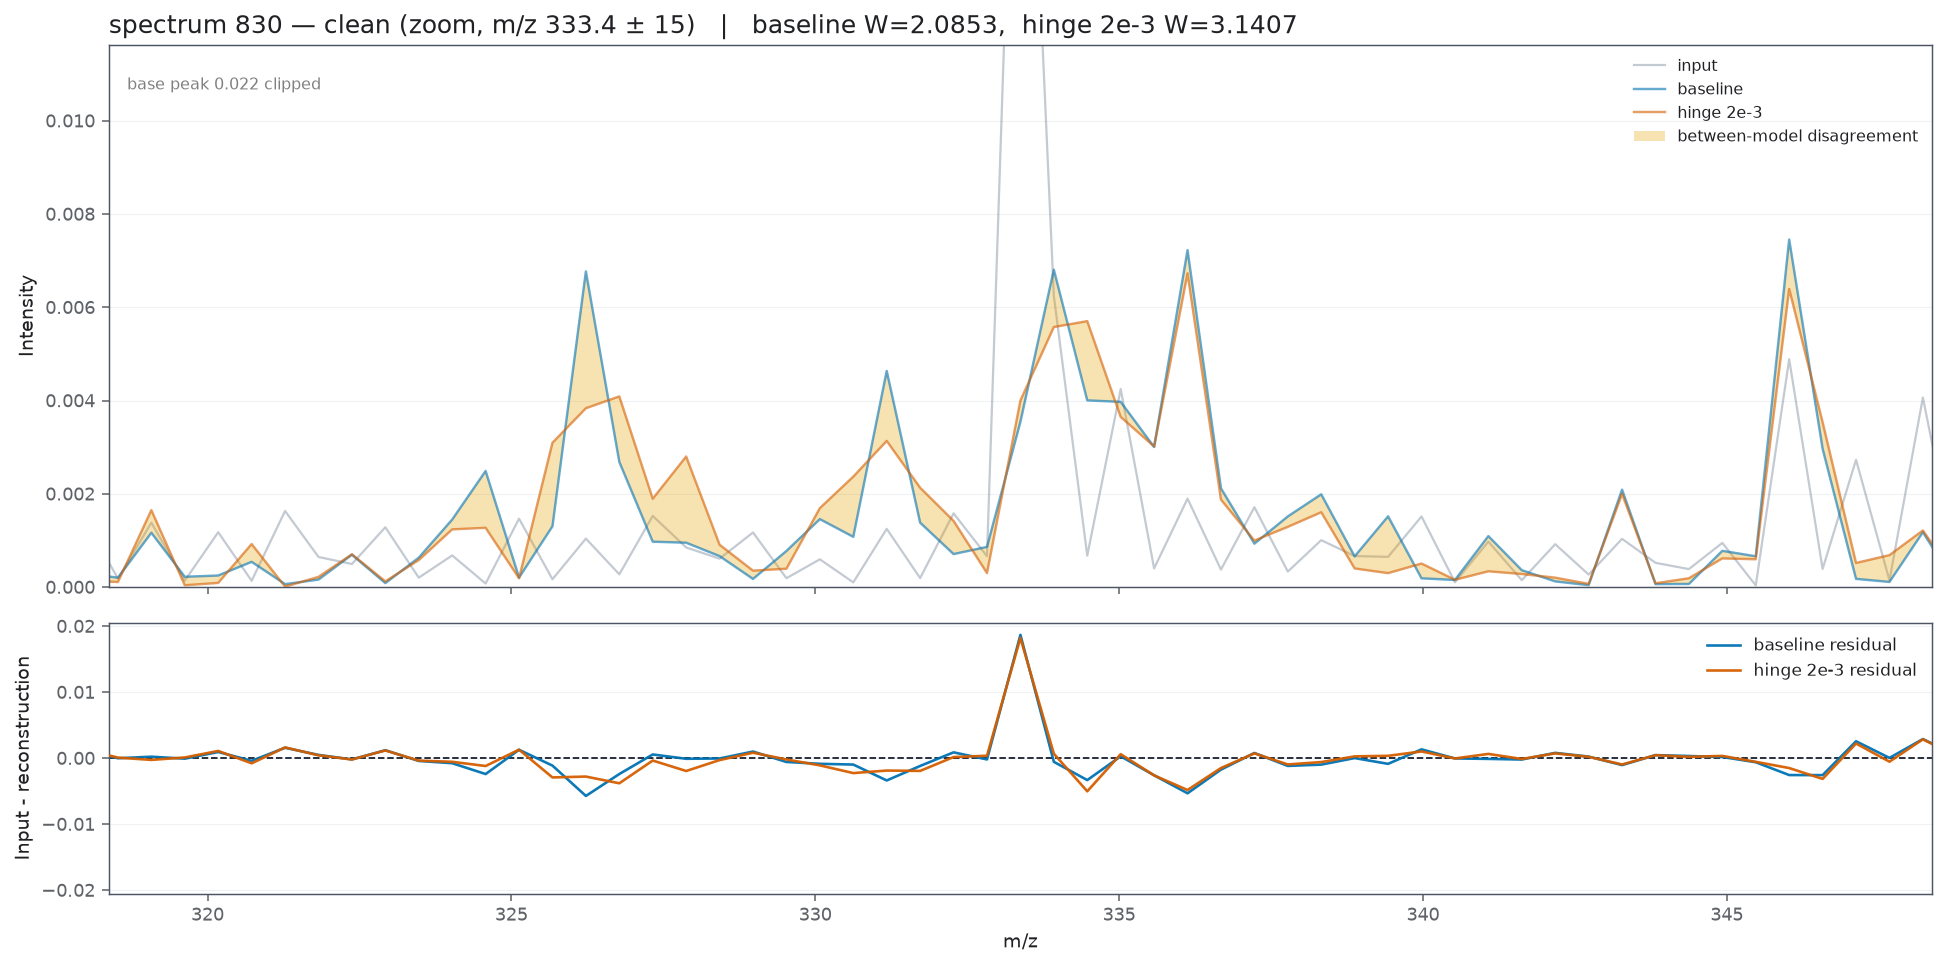

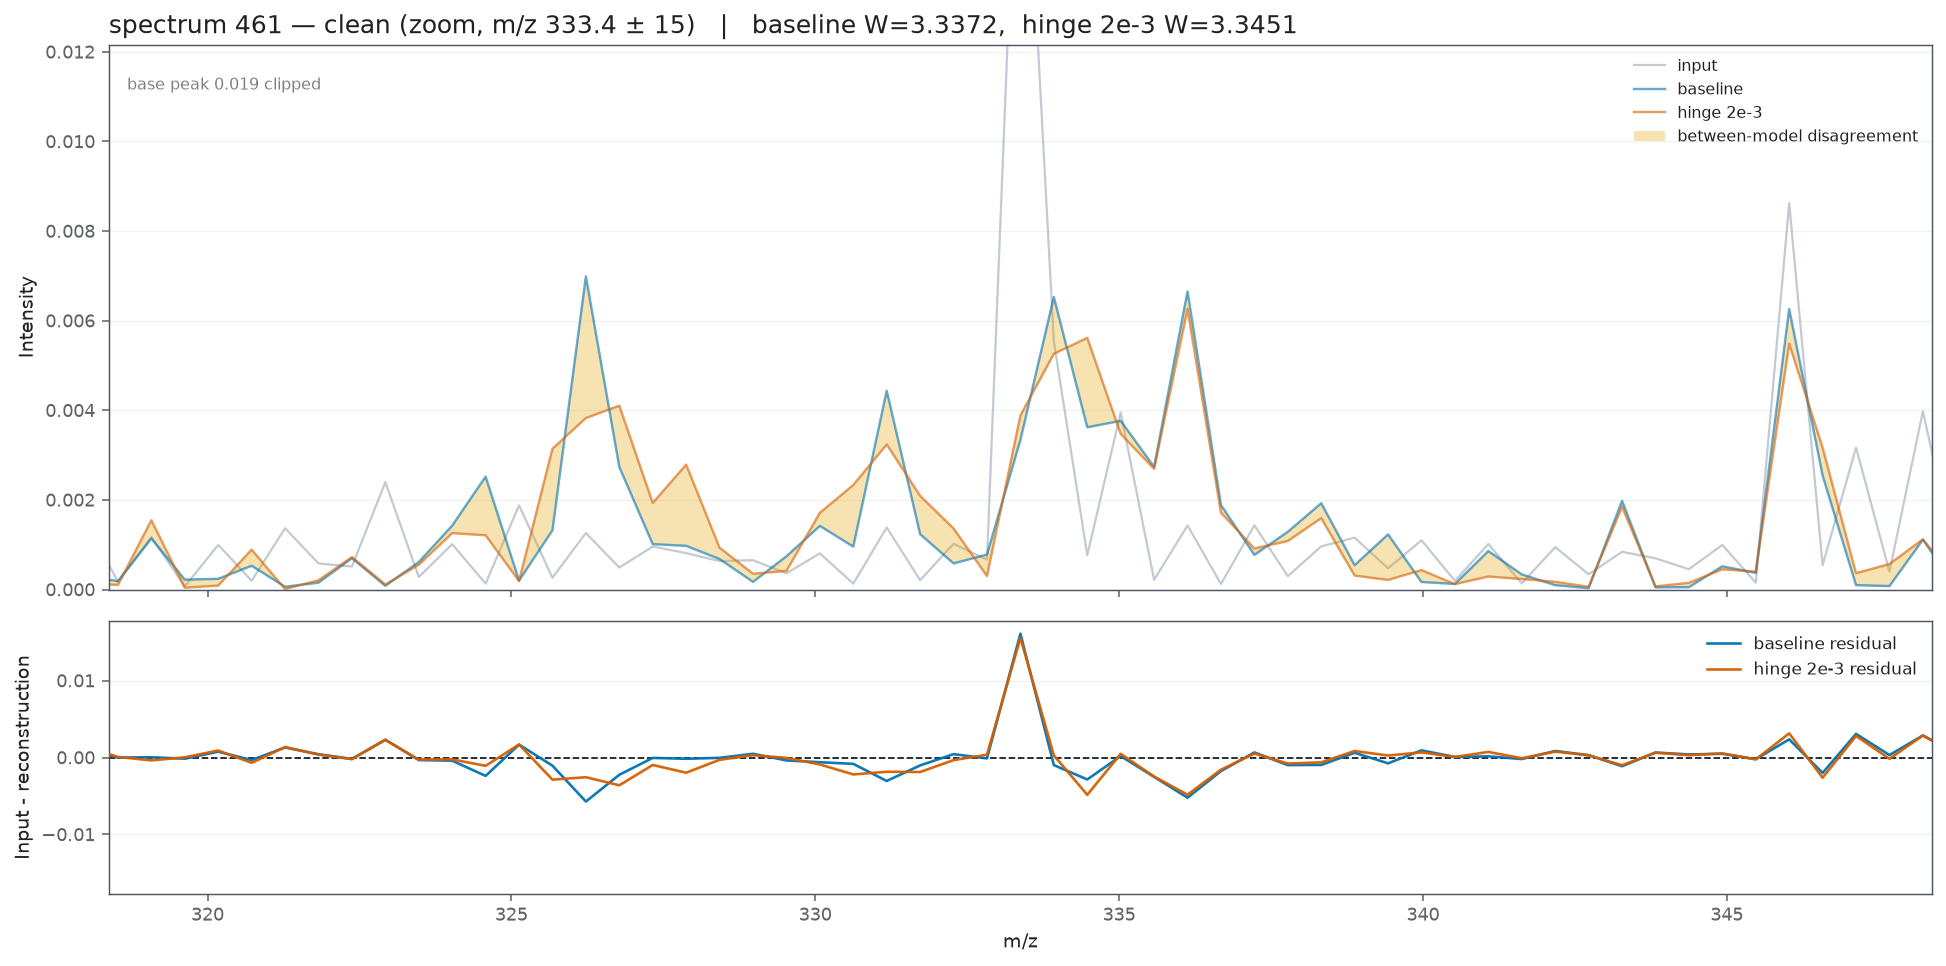

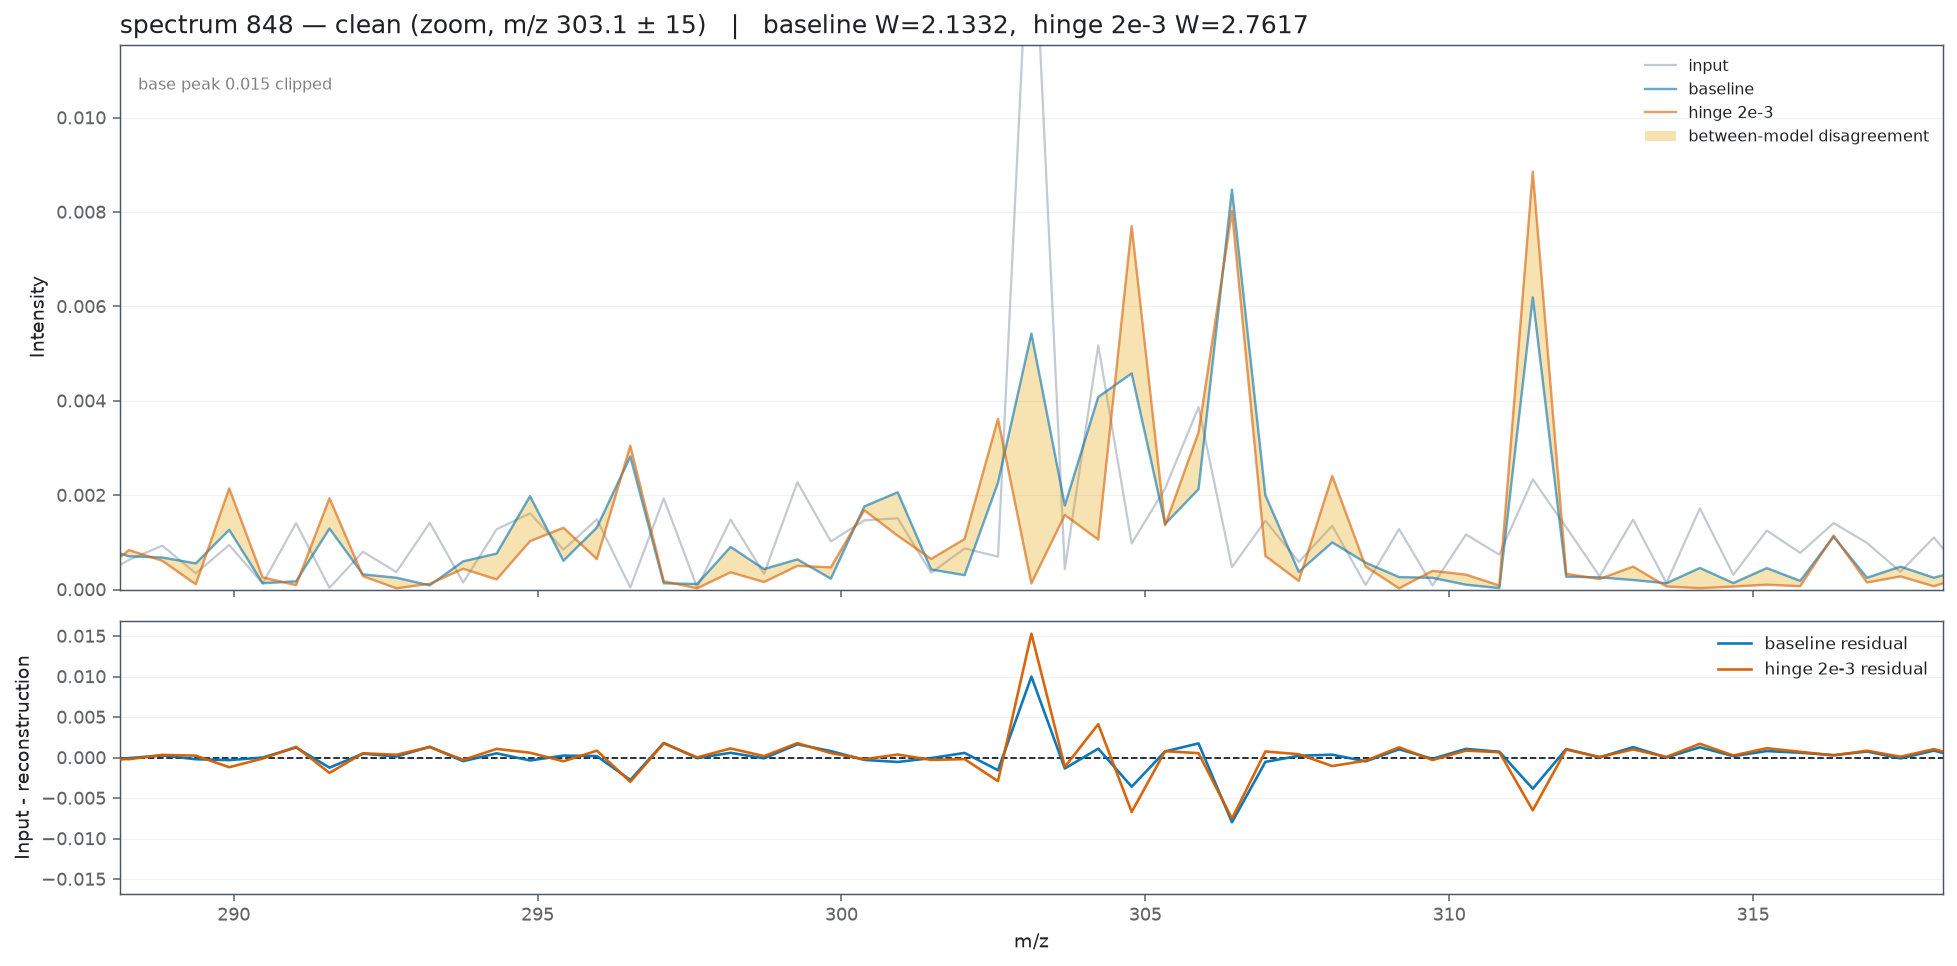

In [5]:
for row in shown_rows:
    row = int(row)
    original = clean[row].cpu().numpy()
    traces = {label: clean_reconstruction[label][row].cpu().numpy() for label in COMPARED}
    costs = spectrum_costs(original, traces)

    figure, (signal_axis, residual_axis) = plot_spectrum_comparison(mass_axis, original, traces, theme=theme)
    figure.set_size_inches(14.0, 7.0)
    low, high = zoom_limits(original)
    window = (mass_axis >= low) & (mass_axis <= high)
    signal_axis.set_xlim(low, high)
    residual_axis.set_xlim(low, high)
    limit, peak_height = display_limit([original, *traces.values()], window)
    signal_axis.set_ylim(0.0, limit)
    if peak_height > limit:
        signal_axis.text(
            0.01, 0.94, f"base peak {peak_height:.3f} clipped", transform=signal_axis.transAxes,
            fontsize=8, va="top", color="grey",
        )
    residual_limit = max(np.abs(original - t)[window].max() for t in traces.values())
    residual_axis.set_ylim(-1.1 * residual_limit, 1.1 * residual_limit)
    signal_axis.fill_between(
        mass_axis, traces["baseline"], traces["hinge 2e-3"],
        color=DISAGREEMENT_COLOR, alpha=0.30, linewidth=0, label="between-model disagreement",
    )
    signal_axis.legend(fontsize=8, frameon=theme.legend_frame)
    cost_text = ",  ".join(f"{label} W={costs[label]:.4f}" for label in COMPARED)
    signal_axis.set_title(
        f"spectrum {test_split.indices[selection][row]} — clean (zoom, m/z {0.5 * (low + high):.1f} ± {ZOOM_HALF_WIDTH_MZ:.0f})   |   {cost_text}",
        loc="left",
    )
    figure.tight_layout()

## Every perturbation and every amplitude, on one figure

### Methodology

#### Theoretical

The notebook's central figure. Each row is one perturbation family and each column one
amplitude, so reading a row left to right shows the spectrum being progressively deformed
and both models responding. The leftmost column is the unperturbed input, so every row
starts from the same reference and the progression is visible rather than inferred.

The shaded band between the two reconstructions is the quantity of interest. On clean
input it is the models' intrinsic disagreement; as the amplitude grows, any widening is the
two encoders responding differently to the same change, which is precisely the effect the
penalty is supposed to produce. A row where the grey input moves a great deal while the
band stays narrow is a perturbation both models handle the same way; a row where the band
opens up is one where the penalty changes the model's behaviour.

#### Implementation

Amplitudes interpolate toward the fully perturbed spectrum and renormalize, so the
perturbation direction stays fixed while its size changes. Both models receive identical
inputs at every amplitude, including identical noise draws for the stochastic families.
Panels within a row share their vertical scale so that movement across the row is
comparable; each panel's title carries both models' latent angular displacement at that
amplitude, tying the picture to `part_5`'s aggregate numbers.

#### Figure descriptions

A grid with one **pair** of rows per perturbation family, named on the left, and one column
per amplitude $t$, named in the panel title together with both latent angles in degrees. The
upper row of each pair shows intensity against m/z: the perturbed input, each model's
reconstruction, and the area between the two reconstructions shaded. The lower row shows the
signed residual, input minus reconstruction, on a symmetric axis with a line at zero, so
over- and under-estimation are distinguishable.

Two scaling choices matter for reading it. The m/z window is fixed for the whole figure,
centred on the strongest peak of the *clean* spectrum, so a displacement appears as the
structure moving through the window rather than as the window following it. The vertical
scale is set from a high quantile of the displayed values rather than from the maximum,
because a TIC-normalized spectrum is dominated by one peak an order of magnitude above the
rest; scaling to it would flatten every other bin onto the axis. Where the base peak exceeds
the panel, its true height is annotated rather than silently cropped. Each row shares one
vertical scale across amplitudes so movement along a row is comparable.

### Remarks

### Notes

,perturbation,amplitude,W baseline,W hinge 2e-3,angle baseline,angle hinge 2e-3
0,mz_shift,0.0,2.0853,3.1407,0.0000,0.0000
1,mz_shift,0.1,2.1049,3.3164,0.6192,0.5639
2,mz_shift,0.5,5.4716,4.2117,7.8302,6.1207
3,mz_shift,1.0,68.7673,38.5989,48.9883,35.2884
4,width_jitter,0.0,2.0853,3.1407,0.0000,0.0000
5,width_jitter,0.1,2.0767,3.3201,0.2880,0.2801
6,width_jitter,0.5,2.1786,3.8165,1.9053,1.8132
7,width_jitter,1.0,5.2281,5.0571,8.7887,6.7254
8,intensity_lognormal,0.0,2.0853,3.1407,0.0000,0.0000
9,intensity_lognormal,0.1,2.0765,3.1218,0.0540,0.0583


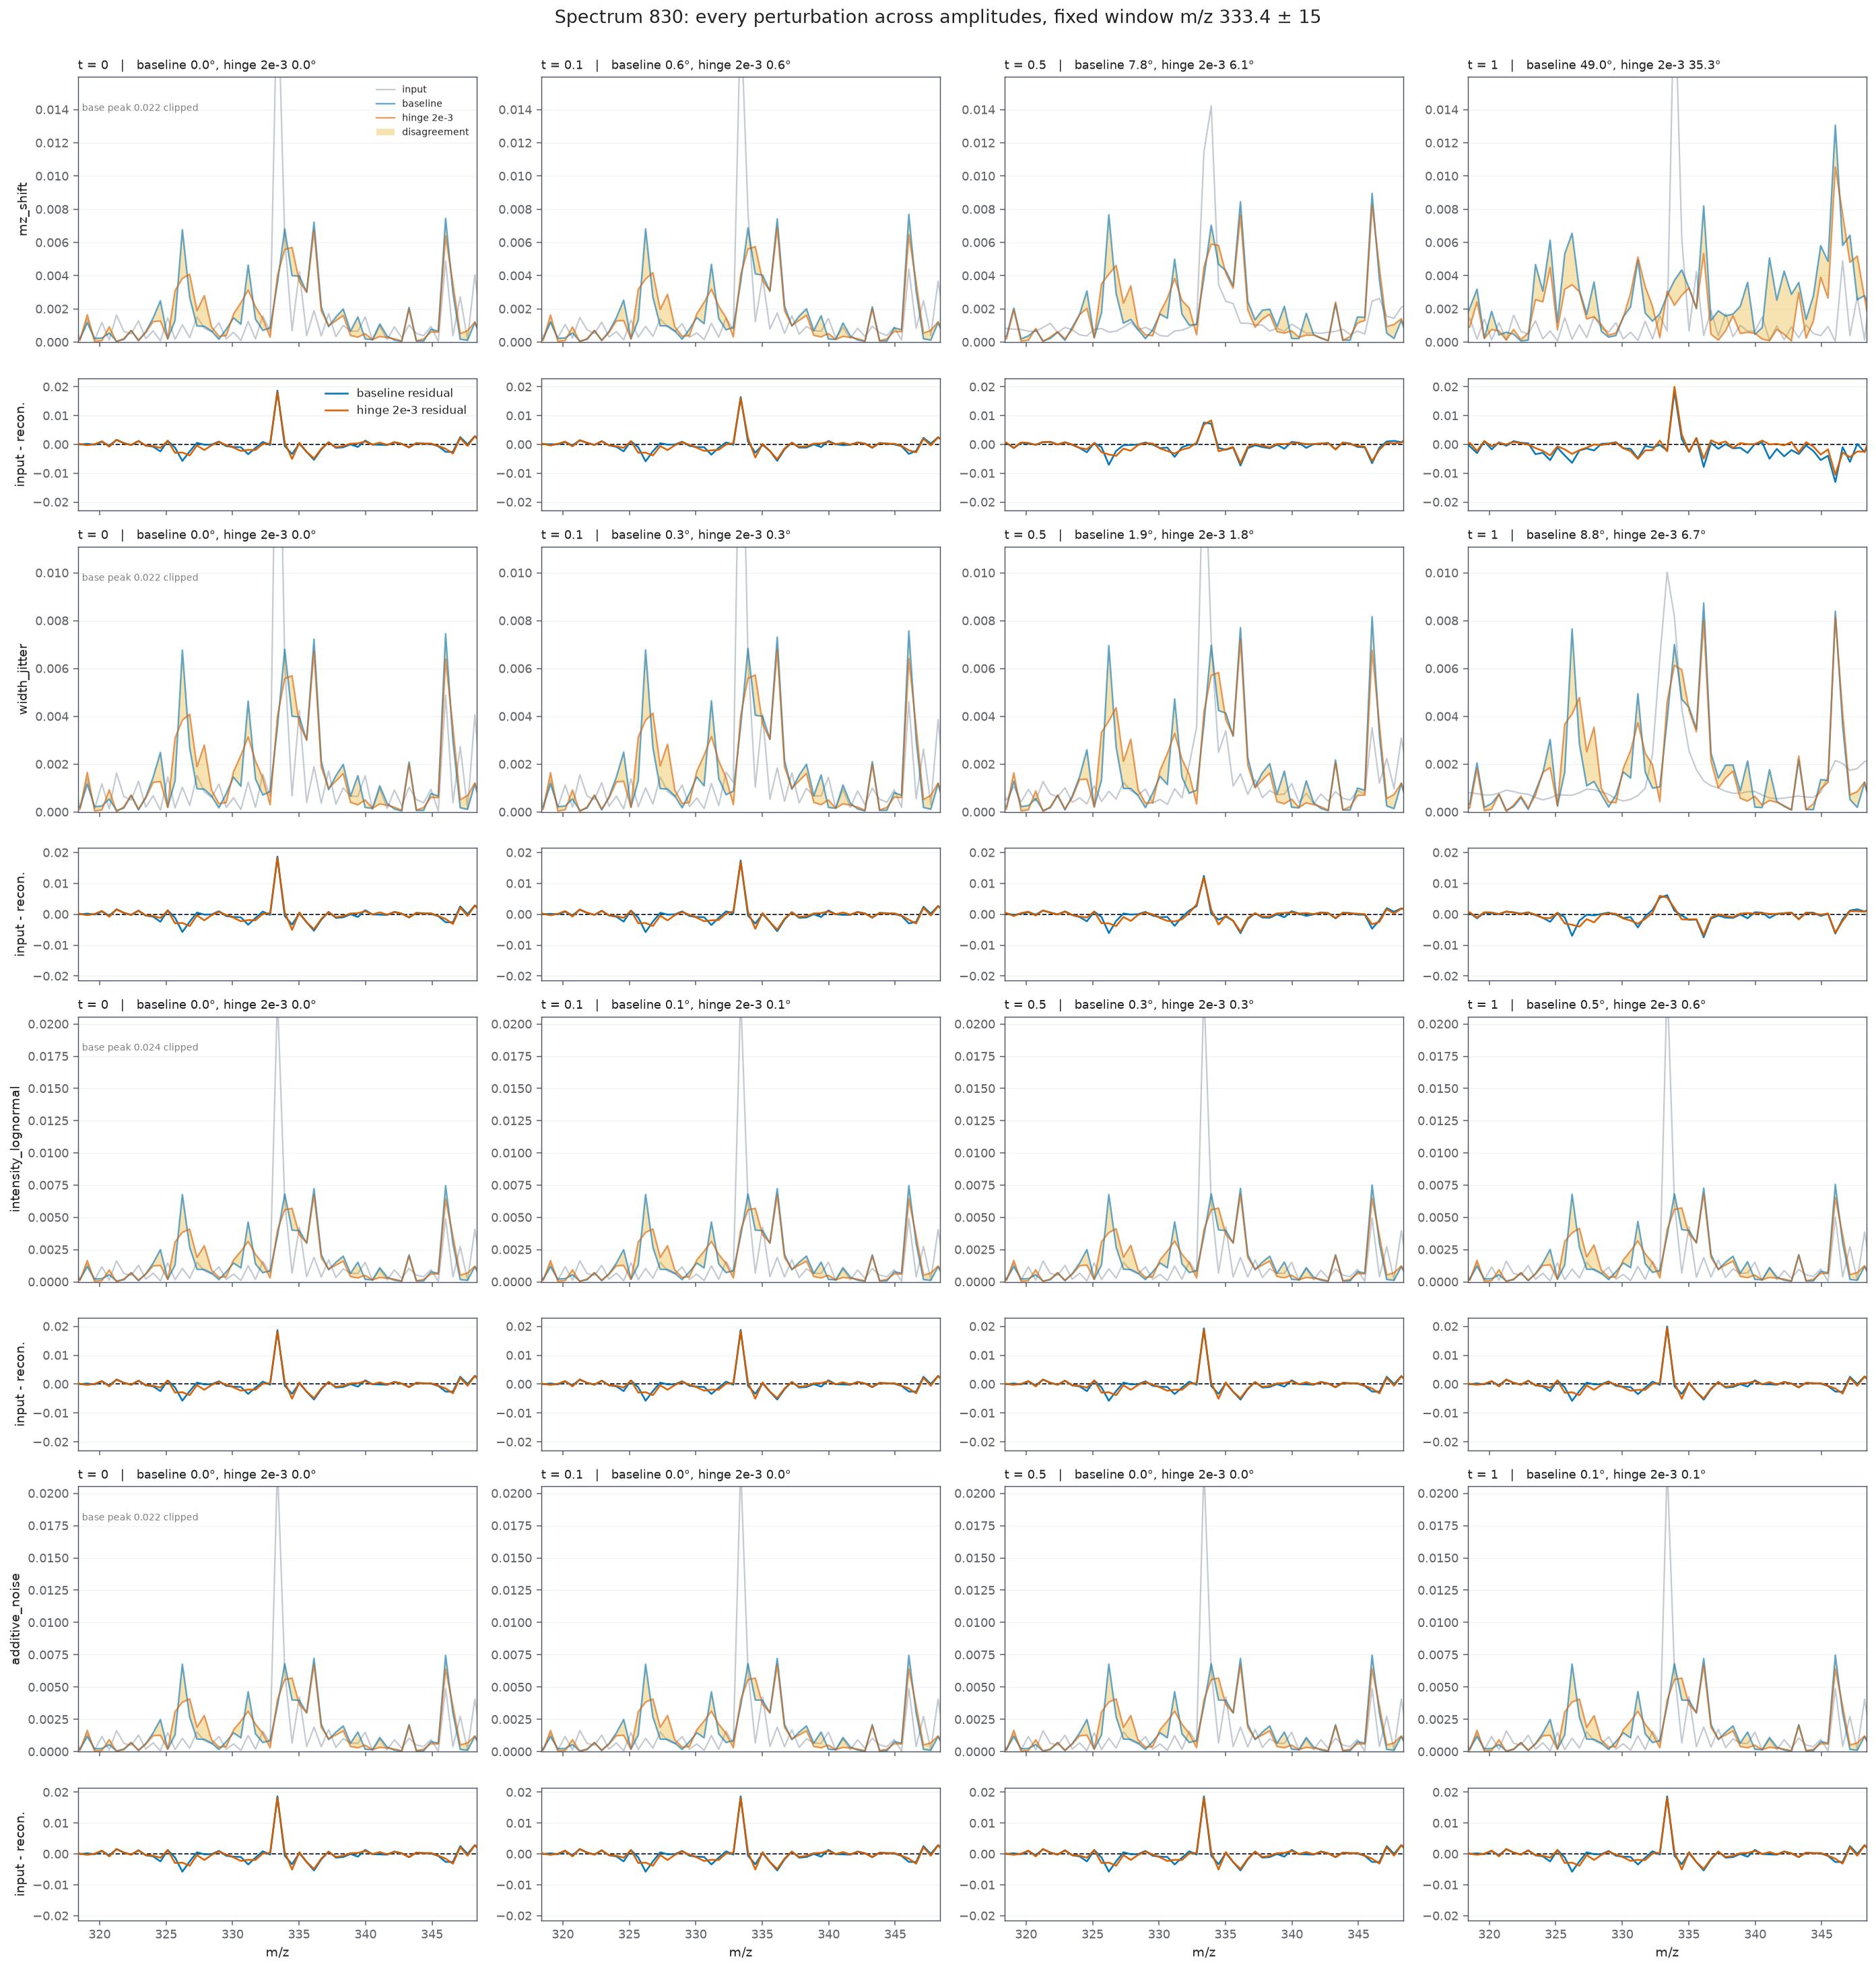

In [6]:
focus_clean = clean[focus_row].cpu().numpy()
zoom_low, zoom_high = zoom_limits(focus_clean)          # fixed for every panel below
zoom_mask = (mass_axis >= zoom_low) & (mass_axis <= zoom_high)

panels = {}
for name, target in targets.items():
    for amplitude in DISPLAY_AMPLITUDES:
        blended = perturbation.interpolate_perturbation(clean, target, amplitude)
        traces, angles = {}, {}
        for label, model in models.items():
            traces[label] = reconstruct(model, blended)[focus_row].cpu().numpy()  # (M,)
            angles[label] = float(np.degrees(
                paired_direction_angles(
                    clean_direction[label][focus_row : focus_row + 1],
                    latent_directions(model, blended[focus_row : focus_row + 1]),
                ).cpu().numpy()[0]
            ))
        spectrum_in = blended[focus_row].cpu().numpy()
        panels[(name, amplitude)] = {
            "input": spectrum_in, "traces": traces, "angles": angles,
            "costs": spectrum_costs(spectrum_in, traces),
        }

rows = 2 * len(perturbation.PERTURBATION_NAMES)
figure, axes = plt.subplots(
    rows, len(DISPLAY_AMPLITUDES),
    figsize=(5.0 * len(DISPLAY_AMPLITUDES), 2.6 * rows), dpi=theme.figure_dpi,
    sharex=True, gridspec_kw={"height_ratios": [2.0, 1.0] * len(perturbation.PERTURBATION_NAMES)},
)
for row, name in enumerate(perturbation.PERTURBATION_NAMES):
    ## One vertical scale per perturbation row, so movement across amplitudes is comparable
    row_traces = [panels[(name, a)][key] for a in DISPLAY_AMPLITUDES
                  for key in ("input",)] + [t for a in DISPLAY_AMPLITUDES for t in panels[(name, a)]["traces"].values()]
    row_limit, row_peak = display_limit(row_traces, zoom_mask)
    residual_limit = 1.15 * max(
        np.abs(panels[(name, a)]["input"] - trace)[zoom_mask].max()
        for a in DISPLAY_AMPLITUDES for trace in panels[(name, a)]["traces"].values()
    )
    for column, amplitude in enumerate(DISPLAY_AMPLITUDES):
        entry = panels[(name, amplitude)]
        signal_axis, residual_axis = axes[2 * row, column], axes[2 * row + 1, column]
        plot_spectrum_comparison(
            mass_axis, entry["input"], entry["traces"],
            axes=(signal_axis, residual_axis), theme=theme,
        )
        signal_axis.fill_between(
            mass_axis, entry["traces"]["baseline"], entry["traces"]["hinge 2e-3"],
            color=DISAGREEMENT_COLOR, alpha=0.30, linewidth=0, label="disagreement",
        )
        signal_axis.set_xlim(zoom_low, zoom_high)
        residual_axis.set_xlim(zoom_low, zoom_high)
        signal_axis.set_ylim(0.0, row_limit)
        residual_axis.set_ylim(-residual_limit, residual_limit)
        angle_text = ", ".join(f"{label} {entry['angles'][label]:.1f}°" for label in COMPARED)
        signal_axis.set_title(f"t = {amplitude:g}   |   {angle_text}", fontsize=9, loc="left")
        signal_axis.set_ylabel(name if column == 0 else "")
        residual_axis.set_ylabel("input - recon." if column == 0 else "")
        residual_axis.set_xlabel("m/z" if row == len(perturbation.PERTURBATION_NAMES) - 1 else "")
        if row == 0 and column == 0:
            signal_axis.legend(fontsize=7, frameon=theme.legend_frame)
        else:
            for axis in (signal_axis, residual_axis):
                legend = axis.get_legend()
                if legend is not None:
                    legend.remove()
    if row_peak > row_limit:
        axes[2 * row, 0].text(
            0.01, 0.90, f"base peak {row_peak:.3f} clipped", transform=axes[2 * row, 0].transAxes,
            fontsize=7, va="top", color="grey",
        )
figure.suptitle(
    f"Spectrum {test_split.indices[selection][focus_row]}: every perturbation across amplitudes, "
    f"fixed window m/z {0.5 * (zoom_low + zoom_high):.1f} ± {ZOOM_HALF_WIDTH_MZ:.0f}",
    y=1.002, fontsize=14,
)
figure.tight_layout()

display(pd.DataFrame([
    {"perturbation": name, "amplitude": amplitude,
     **{f"W {label}": panels[(name, amplitude)]["costs"][label] for label in COMPARED},
     **{f"angle {label}": panels[(name, amplitude)]["angles"][label] for label in COMPARED}}
    for name in perturbation.PERTURBATION_NAMES for amplitude in DISPLAY_AMPLITUDES
]).round(4))

## How the models diverge as the perturbation grows

### Methodology

#### Theoretical

The figure above shows one spectrum; this section measures the same three quantities across
the whole sample so the single-spectrum picture can be checked against the population.

- **Latent displacement** is what the penalty bounds and what `part_5` aggregated.
- **Reconstruction drift** is how far each model's output moves from its own clean output.
  Comparing it to the latent displacement answers whether a stabilized code reaches the
  decoder at all.
- **Between-model disagreement** is the Masserstein distance between the two reconstructions
  at the same amplitude. Unlike the first two it needs no per-model reference, and its growth with
  amplitude is the cleanest single statement of how differently the two encoders behave.

Distributions are reported rather than means, because a difference that holds for the median
pixel and a difference driven by a tail have different consequences for a decision.

#### Implementation

All three are computed over the full spectrum sample at each amplitude, with identical
inputs and identical noise draws for both models. The zero-amplitude point is evaluated
rather than assumed, as a check that the pipeline introduces no spurious displacement.

#### Figure descriptions

Three rows of panels, one column per perturbation family. The top row plots amplitude
against median latent angular displacement in degrees, the middle row against median
reconstruction drift, and the bottom row against median between-model disagreement, all on
logarithmic axes with the zero-amplitude point excluded and reported separately. Lines are
colored by model in the first two rows; the third has one line, since disagreement is a
property of the pair. Lower is less responsive in the first two rows; higher in the third
means the two models are behaving more differently.

### Remarks

### Notes

Zero-amplitude residual (angle and drift): 6.13e-07


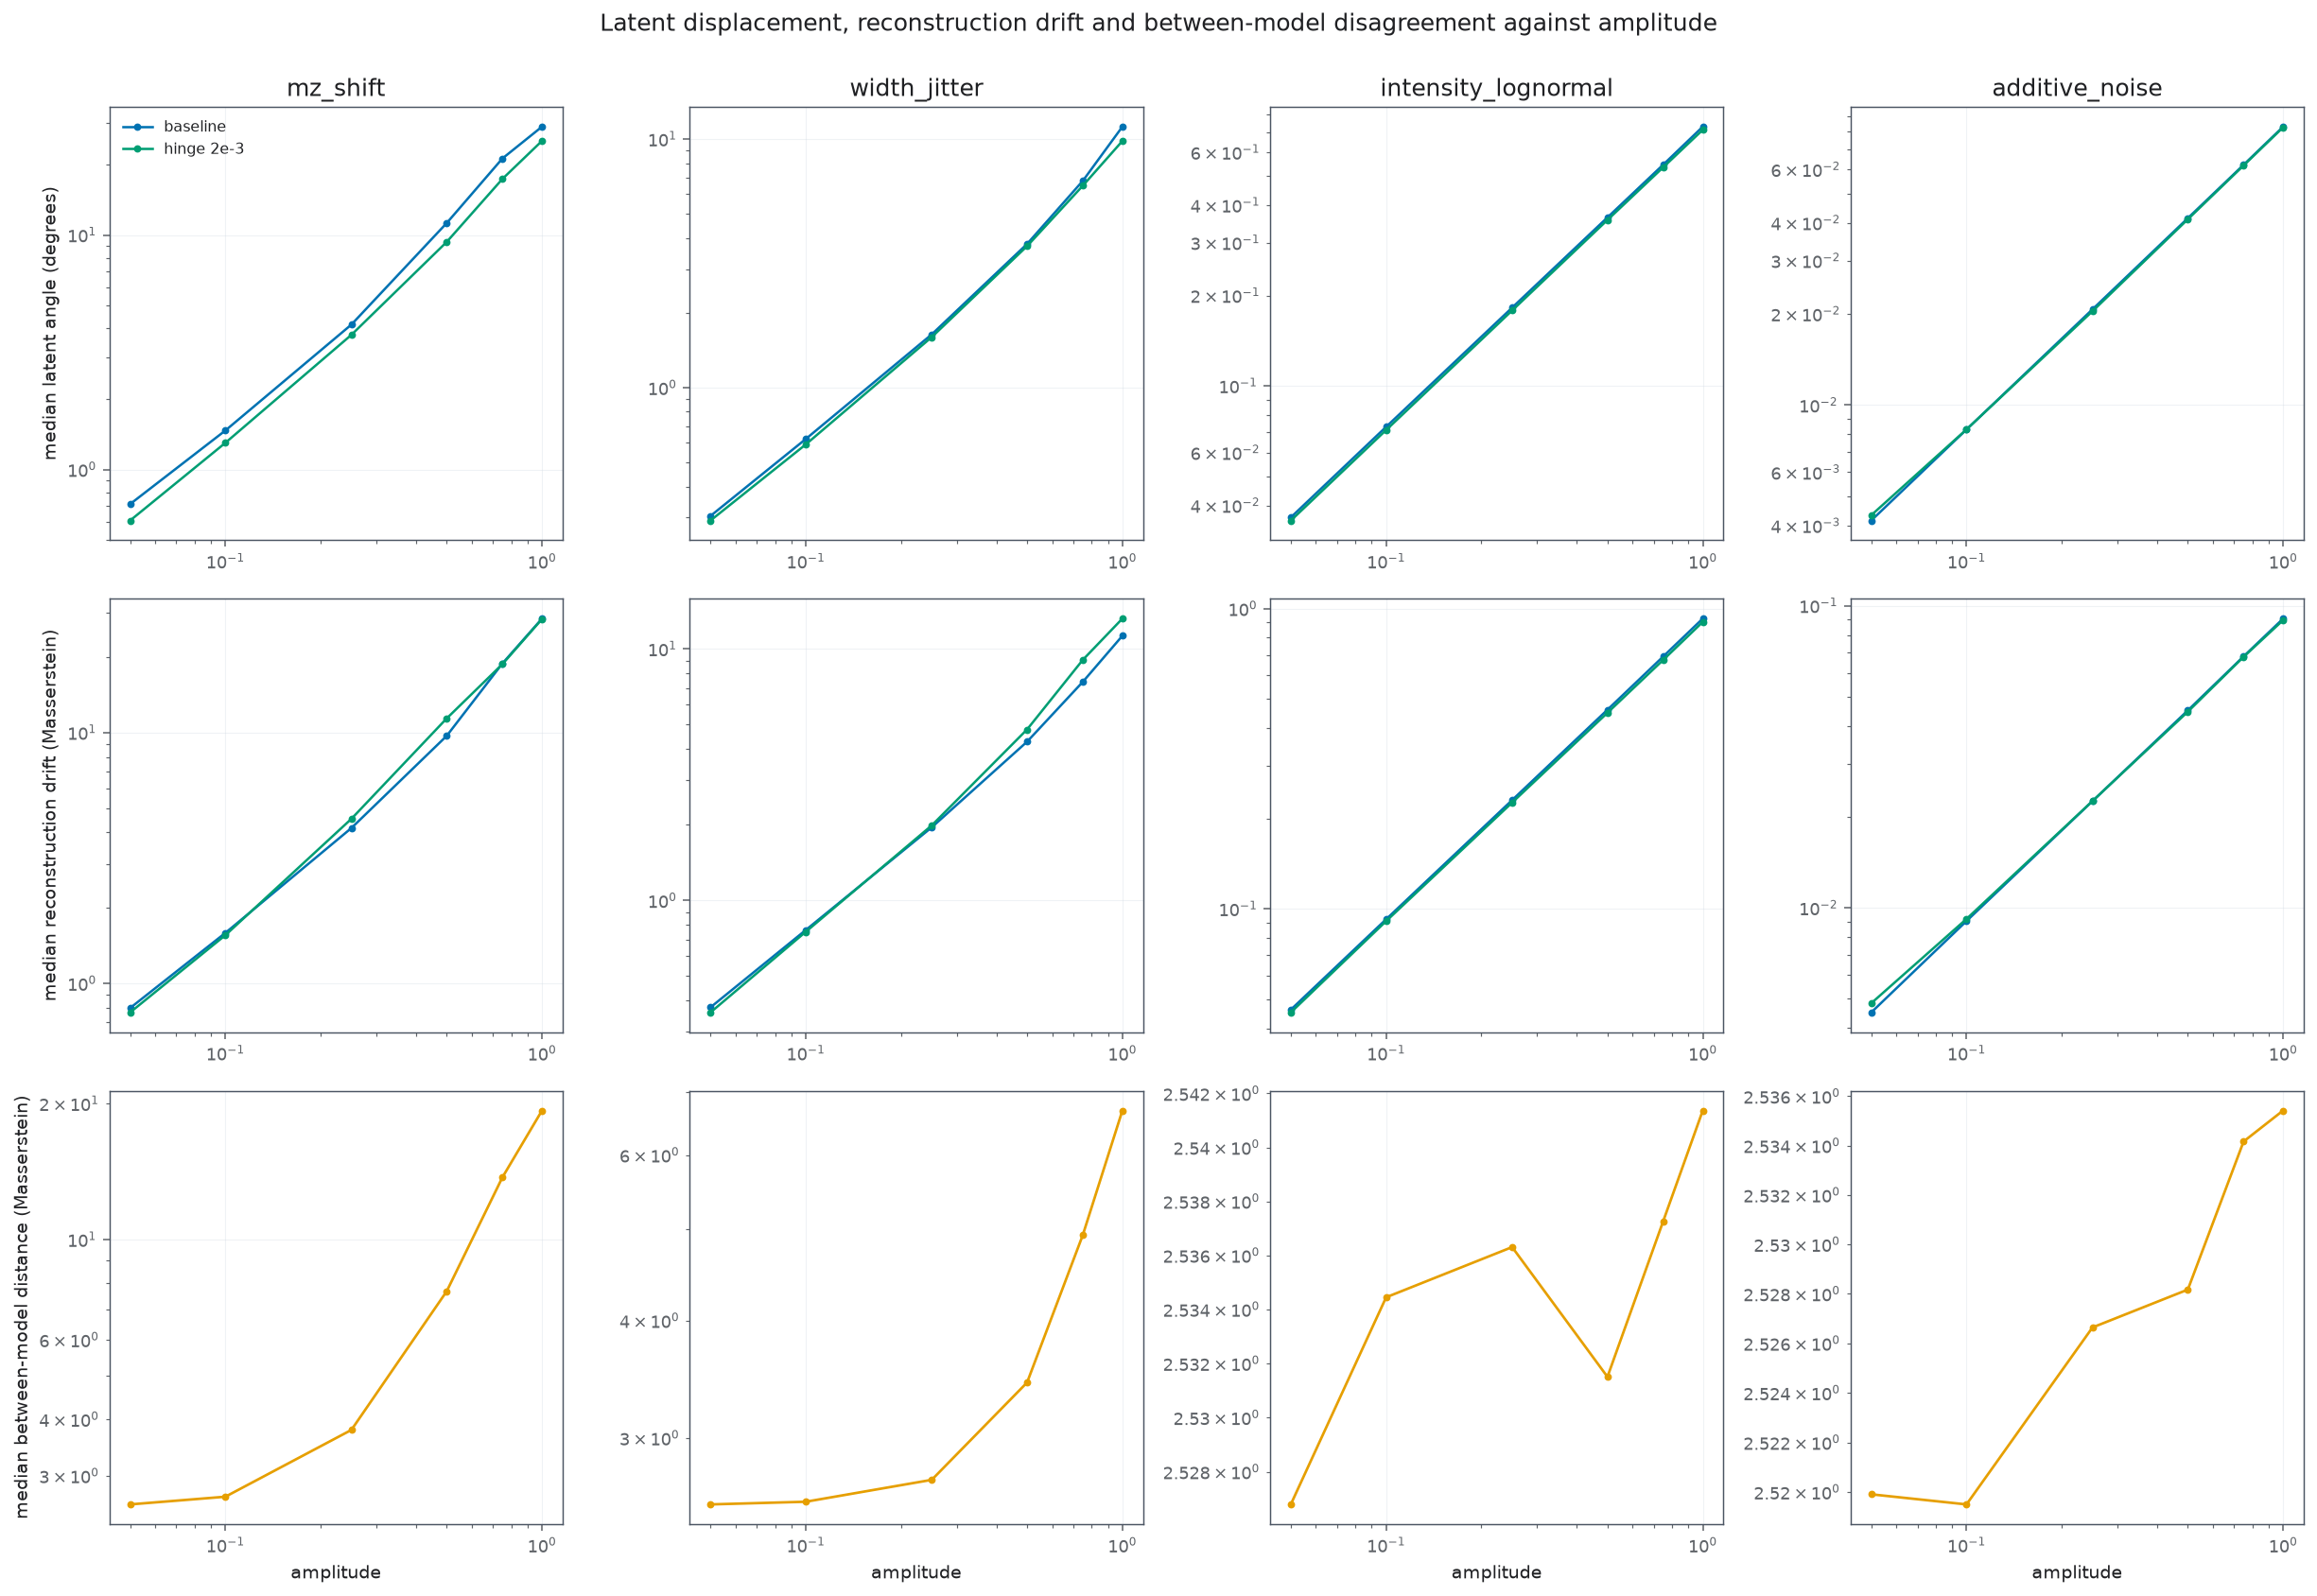

In [7]:
curve_rows, distribution_samples = [], {}
for name, target in targets.items():
    for amplitude in CURVE_AMPLITUDES:
        blended = perturbation.interpolate_perturbation(clean, target, amplitude)
        reconstructions = {}
        for label, model in models.items():
            reconstructions[label] = reconstruct(model, blended)
            angles = np.degrees(
                paired_direction_angles(clean_direction[label], latent_directions(model, blended)).cpu().numpy()
            )
            drift = transport_distance(reconstructions[label], clean_reconstruction[label])  # (N,)
            euclidean_drift = torch.linalg.vector_norm(
                reconstructions[label] - clean_reconstruction[label], dim=1
            ).cpu().numpy()
            curve_rows.append({
                "perturbation": name, "amplitude": float(amplitude), "model": label,
                "median_angle_degrees": float(np.median(angles)),
                "median_drift_masserstein": float(np.median(drift)),
                "median_drift_euclidean": float(np.median(euclidean_drift)),
            })
            if amplitude == 1.0:
                distribution_samples[(name, label, "angle")] = angles
                distribution_samples[(name, label, "drift")] = drift
        disagreement = transport_distance(reconstructions["baseline"], reconstructions["hinge 2e-3"])  # (N,)
        euclidean_disagreement = torch.linalg.vector_norm(
            reconstructions["baseline"] - reconstructions["hinge 2e-3"], dim=1
        ).cpu().numpy()
        curve_rows.append({
            "perturbation": name, "amplitude": float(amplitude), "model": "between models",
            "median_angle_degrees": np.nan,
            "median_drift_masserstein": float(np.median(disagreement)),
            "median_drift_euclidean": float(np.median(euclidean_disagreement)),
        })
        if amplitude in (0.0, 1.0):
            distribution_samples[(name, "between models", f"disagreement_t{amplitude:g}")] = disagreement

curve_frame = pd.DataFrame(curve_rows)
zero_residual = (
    curve_frame.query("amplitude == 0 and model != 'between models'")[["median_angle_degrees", "median_drift_masserstein"]]
    .abs().max().max()
)
print(f"Zero-amplitude residual (angle and drift): {zero_residual:.3g}")

positive = curve_frame.query("amplitude > 0")
figure, axes = plt.subplots(3, len(perturbation.PERTURBATION_NAMES), figsize=(4.4 * len(perturbation.PERTURBATION_NAMES), 12.0), dpi=theme.figure_dpi)
for column, name in enumerate(perturbation.PERTURBATION_NAMES):
    family = positive.query("perturbation == @name")
    for label in COMPARED:
        run = family.query("model == @label").sort_values("amplitude")
        axes[0, column].plot(run["amplitude"], run["median_angle_degrees"], color=MODEL_COLOR[label], marker="o", markersize=3, linewidth=1.3, label=label)
        axes[1, column].plot(run["amplitude"], run["median_drift_masserstein"], color=MODEL_COLOR[label], marker="o", markersize=3, linewidth=1.3, label=label)
    pair = family.query("model == 'between models'").sort_values("amplitude")
    axes[2, column].plot(pair["amplitude"], pair["median_drift_masserstein"], color=DISAGREEMENT_COLOR, marker="o", markersize=3, linewidth=1.4)
    for row, ylabel in ((0, "median latent angle (degrees)"), (1, "median reconstruction drift (Masserstein)"), (2, "median between-model distance (Masserstein)")):
        axes[row, column].set_xscale("log")
        axes[row, column].set_yscale("log")
        axes[row, column].set(xlabel="amplitude" if row == 2 else "", ylabel=ylabel if column == 0 else "", title=name if row == 0 else "")
        axes[row, column].grid(theme.grid_visible, alpha=theme.grid_alpha)
axes[0, 0].legend(fontsize=8, frameon=theme.legend_frame)
figure.suptitle("Latent displacement, reconstruction drift and between-model disagreement against amplitude", y=1.001, fontsize=13)
figure.tight_layout()

## Spread across spectra at full perturbation

### Methodology

#### Theoretical

The curves above report medians. Whether a median difference reflects the typical spectrum
or is produced by a minority of them is a separate question, and it decides how much the
result can be relied on. At full perturbation the per-spectrum values are therefore shown
as distributions.

The between-model disagreement is shown at both zero and full amplitude in the same panel,
which makes the comparison self-contained: the clean-input distribution is the models'
intrinsic difference, and the separation between the two distributions is what the
perturbation added.

#### Implementation

Every spectrum in the sample contributes one value per family. The violins use all of them;
the overlaid points are a fixed subsample drawn with a seeded generator, since one point per
spectrum is unreadable.

#### Figure descriptions

The left panel shows, per family, the distribution across spectra of the latent angular
displacement at full perturbation, one violin per model, on a logarithmic y-axis. The middle
panel shows reconstruction drift in the same layout. The right panel shows the between-model
disagreement with two violins per family, one at zero amplitude and one at full amplitude, so
the widening attributable to the perturbation is read as the gap between the pair.

### Remarks

### Notes

model,baseline,between models,hinge 2e-3
perturbation,,,
additive_noise,0.09065,2.53542,0.08959
intensity_lognormal,0.92637,2.54137,0.90294
mz_shift,28.47687,19.31754,28.35734
width_jitter,11.28542,6.69178,13.20881


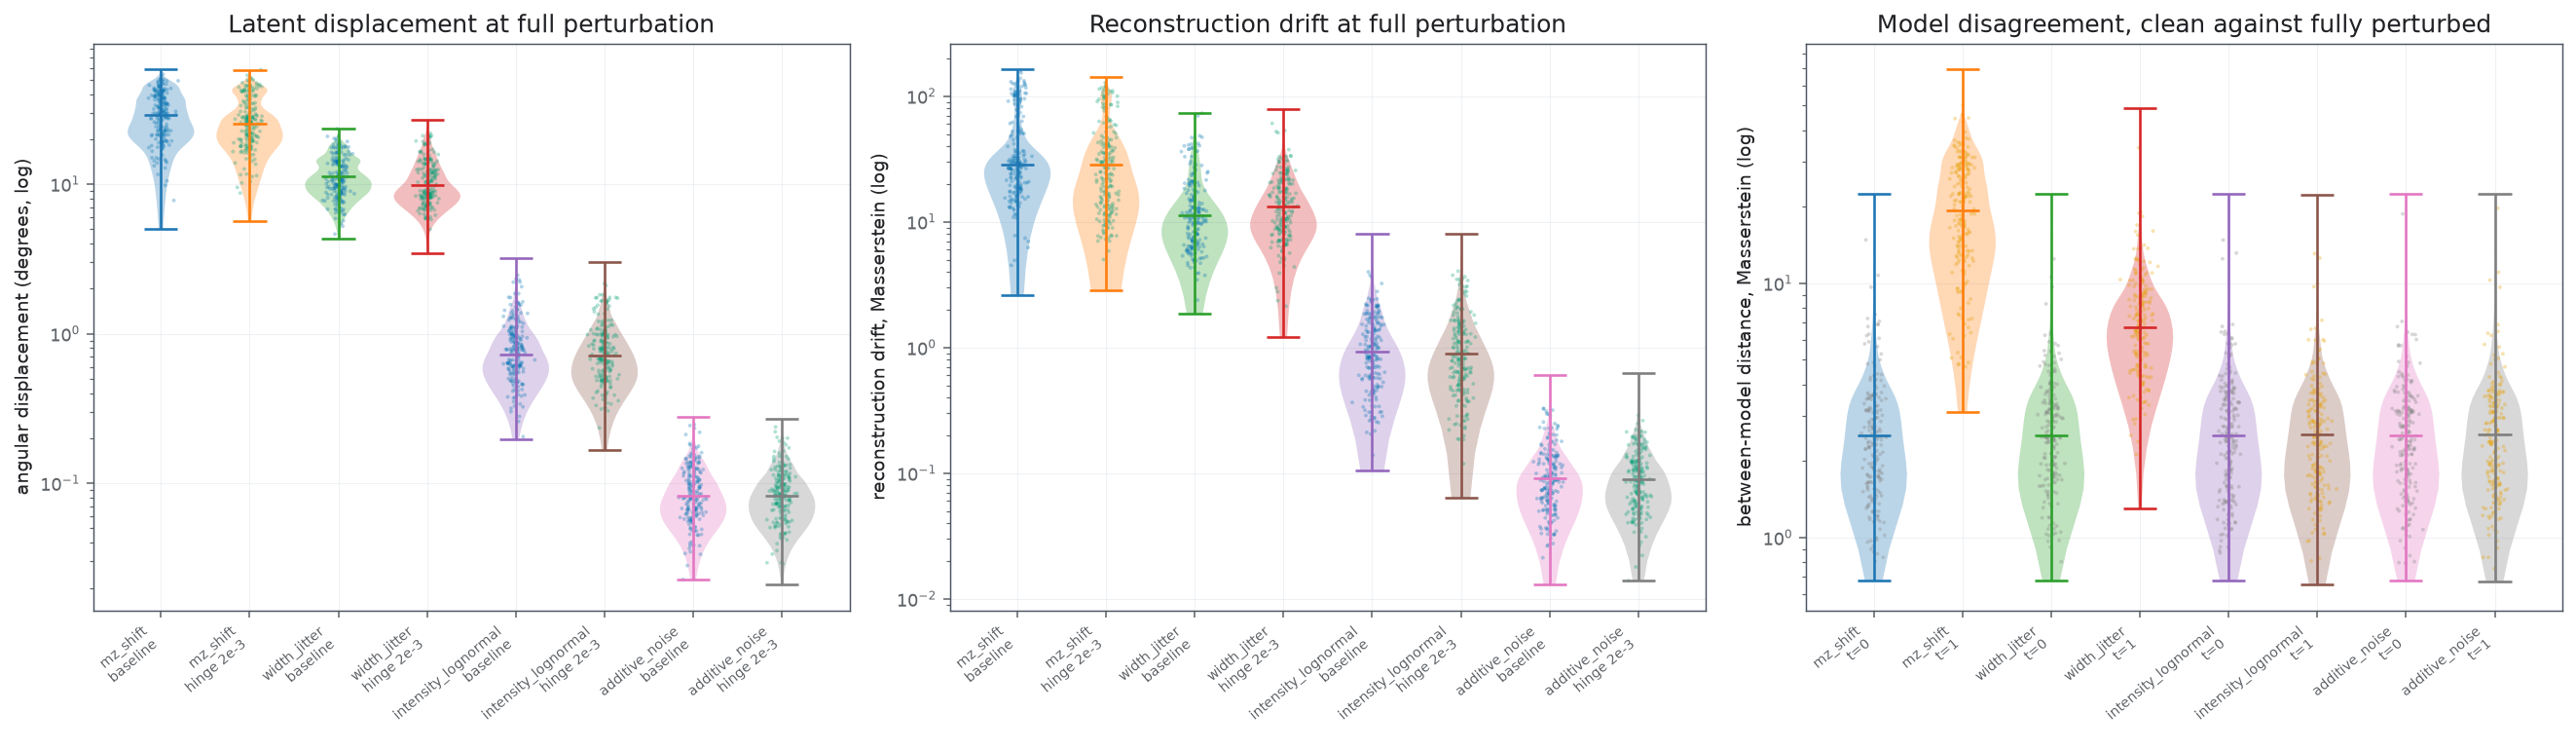

In [8]:
point_rng = np.random.default_rng(SAMPLE_SEED + 11)
POINT_SAMPLE = 200


def draw_group(axis, samples_by_position, labels, colors, ylabel, title):
    for position, values in samples_by_position.items():
        values = np.asarray(values)
        values = values[values > 0]
        if not len(values):
            continue
        axis.violinplot([values], positions=[position], widths=0.75, showmedians=True)
        shown = point_rng.choice(values, min(POINT_SAMPLE, len(values)), replace=False)
        axis.scatter(position + point_rng.normal(0.0, 0.06, size=len(shown)), shown,
                     color=colors[position], s=4, alpha=0.3, edgecolor="none")
    axis.set_yscale("log")
    axis.set_xticks(list(labels))
    axis.set_xticklabels(list(labels.values()), rotation=40, ha="right", fontsize=7)
    axis.set(ylabel=ylabel, title=title)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)


figure, axes = plt.subplots(1, 3, figsize=(19.0, 5.6), dpi=theme.figure_dpi)
for axis, (kind, ylabel, title) in zip(
    axes[:2],
    (("angle", "angular displacement (degrees, log)", "Latent displacement at full perturbation"),
     ("drift", "reconstruction drift, Masserstein (log)", "Reconstruction drift at full perturbation")),
):
    samples, labels, colors = {}, {}, {}
    position = 0
    for name in perturbation.PERTURBATION_NAMES:
        for label in COMPARED:
            samples[position] = distribution_samples[(name, label, kind)]
            labels[position] = f"{name}\n{label}"
            colors[position] = MODEL_COLOR[label]
            position += 1
    draw_group(axis, samples, labels, colors, ylabel, title)

samples, labels, colors = {}, {}, {}
position = 0
for name in perturbation.PERTURBATION_NAMES:
    for amplitude in (0.0, 1.0):
        samples[position] = distribution_samples[(name, "between models", f"disagreement_t{amplitude:g}")]
        labels[position] = f"{name}\nt={amplitude:g}"
        colors[position] = "grey" if amplitude == 0.0 else DISAGREEMENT_COLOR
        position += 1
draw_group(axes[2], samples, labels, colors, "between-model distance, Masserstein (log)", "Model disagreement, clean against fully perturbed")
figure.tight_layout()

display(
    curve_frame.query("amplitude == 1.0")
    .pivot_table(index="perturbation", columns="model", values="median_drift_masserstein")
    .round(5)
)

## Reproducible artifacts

### Methodology

#### Implementation

The amplitude curves, the full-perturbation per-spectrum distributions and the identity of
the two compared models are persisted, together with the dataset indices of the analysed and
displayed spectra. Provenance records the perturbation settings, the amplitude schedules,
seeds, library versions, the commit and a hash of the perturbation module.

### Remarks

### Notes

In [9]:
distribution_frame = pd.DataFrame([
    {"perturbation": name, "model": label, "quantity": kind,
     "row": index, "dataset_index": int(test_split.indices[selection][index]), "value": float(value)}
    for (name, label, kind), values in distribution_samples.items()
    for index, value in enumerate(values)
])

frames = {
    "amplitude_curves": curve_frame,
    "full_perturbation_distributions": distribution_frame,
    "models": grid_frame,
}
for name, frame in frames.items():
    frame.to_csv(ARTIFACT_DIR / f"{name}.csv", index=False)
pd.DataFrame({"dataset_index": test_split.indices[selection]}).to_csv(ARTIFACT_DIR / "analysed_spectra.csv", index=False)

metadata = {
    "compared_models": {label: model_name_by_cell[cell] for label, cell in COMPARED.items()},
    "compared_cells": COMPARED,
    "repetition": REPETITION,
    "perturbations": list(perturbation.PERTURBATION_NAMES),
    "settings": {
        "shift_bins": PERTURBATION_SETTINGS.shift_bins,
        "extra_width_sigma": PERTURBATION_SETTINGS.extra_width_sigma,
        "base_width_sigma": PERTURBATION_SETTINGS.base_width_sigma,
        "lognormal_sigma": PERTURBATION_SETTINGS.lognormal_sigma,
        "noise_fraction": PERTURBATION_SETTINGS.noise_fraction,
    },
    "display_amplitudes": list(DISPLAY_AMPLITUDES),
    "curve_amplitudes": list(CURVE_AMPLITUDES),
    "analysed_spectra": int(clean.shape[0]),
    "focus_dataset_index": int(test_split.indices[selection][focus_row]),
    "displayed_dataset_indices": test_split.indices[selection][shown_rows].tolist(),
    "zoom_half_width_mz": ZOOM_HALF_WIDTH_MZ,
    "mass_axis_range": [float(mass_axis[0]), float(mass_axis[-1])],
    "sample_seed": SAMPLE_SEED,
    "zero_amplitude_residual": float(zero_residual),
    "numpy": np.__version__,
    "torch": torch.__version__,
    "git_commit": subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip(),
    "perturbations_sha256": hashlib.sha256(Path("src/msi_autoencoder_wrapper/analysis/autoencoder/latent/perturbations.py").read_bytes()).hexdigest(),
}
(ARTIFACT_DIR / "metadata.json").write_text(json.dumps(metadata, indent=2) + "\n")
logger.info("Wrote %s table(s) and provenance to %s", len(frames), ARTIFACT_DIR)
print(sorted(path.name for path in ARTIFACT_DIR.iterdir()))

2026-09-07 22:32:18,227 | INFO     | spectrum_reconstruction:44 | Wrote 3 table(s) and provenance to assets/experiments/autoencoder_architecture/notebooks/05_09_26_contractive_expaned/part_6_spectrum_reconstruction_results


['amplitude_curves.csv', 'analysed_spectra.csv', 'full_perturbation_distributions.csv', 'metadata.json', 'models.csv']


## Results / Summary

### LLM

**Changing the distance to the training objective reverses one conclusion and removes
another, which is itself evidence that the metric choice is not cosmetic.** An earlier
version of this notebook measured reconstruction movement with the Euclidean norm. Under the
Masserstein cost the models were actually trained to minimize, two of its readings do not
survive. This is the same phenomenon `part_0_3` documents for perturbation lengths, appearing
now on the output side.

**The encoder's stabilization does not reach the output for the m/z shift.** `part_5` and the
panels above show the penalized model's latent direction moving 13% less under a one-bin
shift, but at full perturbation the reconstruction drift is 28.36 against the baseline's
28.48, a difference of 0.4%. The decoder absorbs essentially the whole of the encoder's
advantage in this direction. The Euclidean view suggested a 1.3% difference, so the
qualitative conclusion is the same but the effect is smaller still.

**Under peak broadening the penalized model drifts more, not less.** Masserstein drift is
13.21 against the baseline's 11.29, a 17% increase, where the Euclidean norm reported a 10%
decrease. The reversal is informative rather than contradictory: the ratio of the two
distances differs by model, 828 for the baseline and 1076 for the penalized one, meaning the
penalized model's reconstruction error under broadening is displaced along the m/z axis
rather than changed in amplitude. A transport cost charges for that displacement and a
Euclidean norm does not. Reading robustness off the Euclidean norm would have credited the
penalty with an improvement it does not have on its own objective.

**The two models diverge sharply under geometric perturbation and not at all under intensity
noise.** Between-model disagreement is 2.52 on clean input for every family by construction,
and at full perturbation reaches 19.32 for the m/z shift and 6.69 for broadening, increases
of 667% and 166%, while the two intensity families end at 2.54 and 2.54, within 1% of where
they started. The widening is confined to exactly the families `part_5` found the penalty
acting on, which is the internal consistency check this measurement provides: a numerical
artifact would widen everywhere.

**A scale claim from the Euclidean version does not hold.** That version reported the two
models differing more from each other on clean input than either moved under perturbation.
Under the transport cost the clean disagreement, 2.52, is an order of magnitude below the
perturbation-induced drift of 28.5 for the shift. The earlier statement was an artifact of a
norm that rates a one-bin displacement as a near-total change, and should not be carried
forward.

**Pipeline check.** The zero-amplitude residual is $6.1\times10^{-7}$, so the amplitude sweep
starts from an exact zero.

**Caveat.** All figures use repetition 0 of each configuration. `part_5` established the
direction of the latent-space effects across five repetitions with paired intervals; the
reconstruction-side differences reported here are single-repetition and are not accompanied
by intervals, so the broadening reversal in particular should be confirmed across seeds
before it is relied on.

### Person